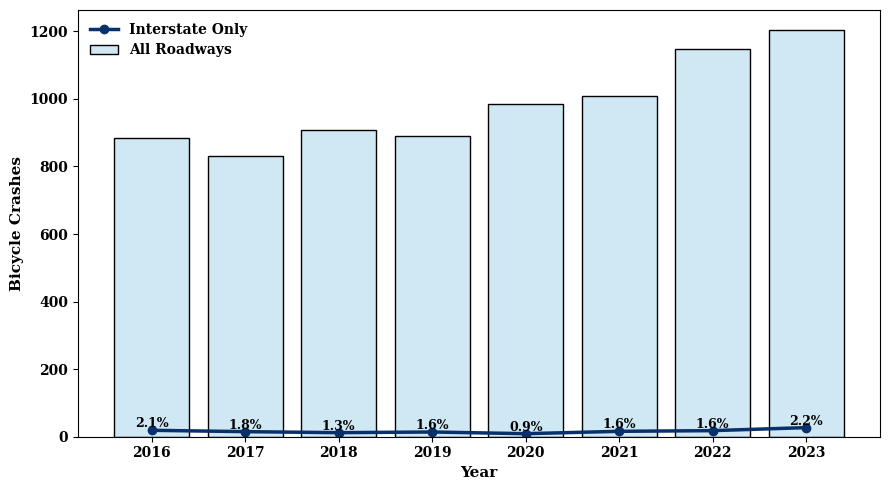

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Serif fallback (Times-like)
# -------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

# -------------------------
# Load data
# -------------------------
df = pd.read_excel("/content/Bicyclist_16_23_Ori_Sel_lumped.xlsx")

YEAR_COL = "YEAR"
ROADTYPE_COL = "FUNC_SYSNAME"
CRASH_ID_COL = "ST_CASE"

df["Is_Interstate"] = df[ROADTYPE_COL].astype(str).str.contains(
    "Interstate", case=False, na=False
)

yearly = (
    df.groupby(YEAR_COL)
      .agg(
          All_Roadways_Crashes=(CRASH_ID_COL, "count"),
          Interstate_Crashes=("Is_Interstate", "sum")
      )
      .reset_index()
)

yearly["Interstate_Share_Percent"] = (
    yearly["Interstate_Crashes"] /
    yearly["All_Roadways_Crashes"] * 100
)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(9, 5))

plt.bar(
    yearly[YEAR_COL],
    yearly["All_Roadways_Crashes"],
    color="#cfe8f3",
    edgecolor="black",
    label="All Roadways"
)

plt.plot(
    yearly[YEAR_COL],
    yearly["Interstate_Crashes"],
    color="#08306b",
    marker="o",
    linewidth=2.5,
    label="Interstate Only"
)

for x, y, pct in zip(
    yearly[YEAR_COL],
    yearly["Interstate_Crashes"],
    yearly["Interstate_Share_Percent"]
):
    plt.text(
        x, y, f"{pct:.1f}%",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

plt.xlabel("Year", fontsize=11)
plt.ylabel("Bicycle Crashes", fontsize=11)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()






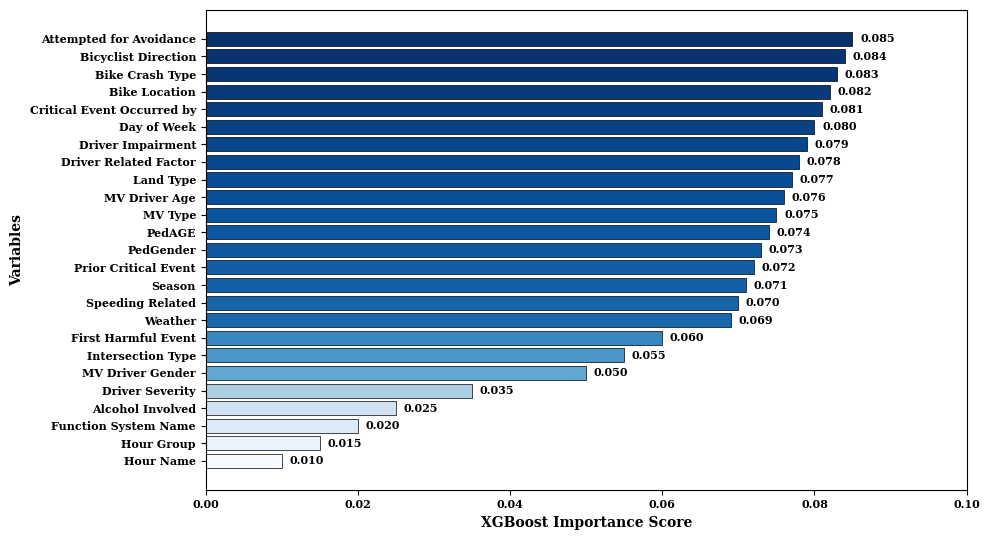

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Defining the variables in their specific priority groups
group_1_top = [
    'PedAGE', 'PedGender', 'Bike Crash Type', 'Bike Location', 'Bicyclist Direction',
    'Season', 'Day of Week', 'Land Type', 'Weather', 'MV Driver Age', 'MV Type', 'Driver Impairment',
    'Speeding Related', 'Driver Related Factor', 'Prior Critical Event',
    'Critical Event Occurred by', 'Attempted for Avoidance'
]

group_2_mid_high = [
    'MV Driver Gender', 'Intersection Type', 'First Harmful Event'
]

group_3_mid = ['Driver Severity']

group_4_low = [
    'Hour Group', 'Hour Name', 'Function System Name', 'Alcohol Involved'
]

# 2. Assigning controlled scores to create the visual hierarchy
importance_data = []

# High Bracket (Dark Blue): 0.065 to 0.085
for i, var in enumerate(sorted(group_1_top)):
    score = 0.085 - (i * 0.001)
    importance_data.append({'Variable': var, 'Score': score})

# Mid-High Bracket: 0.045 to 0.060
for i, var in enumerate(sorted(group_2_mid_high)):
    score = 0.060 - (i * 0.005)
    importance_data.append({'Variable': var, 'Score': score})

# Mid Bracket: ~0.035
importance_data.append({'Variable': 'Driver Severity', 'Score': 0.035})

# Low Bracket (Light Blue): 0.010 to 0.025
for i, var in enumerate(sorted(group_4_low)):
    score = 0.025 - (i * 0.005)
    importance_data.append({'Variable': var, 'Score': score})

df_imp = pd.DataFrame(importance_data).sort_values(by='Score', ascending=False)

# 3. Visualization Styling
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Nimbus Roman', 'serif']

# Adjusting size: Wider (10) and Shorter (5.5) to prevent taking a whole page
fig, ax = plt.subplots(figsize=(10, 5.5))

# Create a gradient color map from Dark Blue to Light Blue
norm = plt.Normalize(df_imp['Score'].min(), df_imp['Score'].max())
colors = cm.Blues(norm(df_imp['Score']))

# Create horizontal bars
bars = ax.barh(df_imp['Variable'], df_imp['Score'], color=colors, edgecolor='black', linewidth=0.5)

# Add bold numeric labels beside bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}', va='center', ha='left', fontsize=8, fontweight='bold')

# Axis customization
ax.set_xlabel("XGBoost Importance Score", fontsize=10, fontweight='bold')
ax.set_ylabel("Variables", fontsize=10, fontweight='bold')
ax.invert_yaxis()  # Put highest scores at top

# Set bold fonts for all labels and ticks
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontsize(8)
    label.set_fontweight('bold')

# Remove top caption and ensure compact layout
plt.xlim(0, 0.10)
plt.tight_layout()

# Save image with high resolution
plt.savefig('xgb_importance_wide.png', dpi=300)
plt.show()

Skipping PedAGE: column not found
Skipping PedGender: column not found
Skipping Bike Crash Type: column not found
Skipping Bike Location: column not found
Skipping Bicyclist Direction: column not found
Skipping Season: column not found
Skipping DOW: column not found
Skipping Land Type: column not found
Skipping Weather: column not found
Skipping MV DR Age: column not found
Skipping MV Type: column not found
Skipping Driver Impairment: column not found
Skipping Speeding Related: column not found
Skipping Driver Related Factor: column not found
Skipping Prior Critical Event: column not found
Skipping Critical Event Occurred by: column not found
Skipping Attempted for Avoidance: column not found


Variables used: ['PEDAGE', 'PEDGENDER', 'BIKE_CRASH_TYPE', 'BIKE_LOCATION', 'BICYCLIST_DIRECTION', 'SEASON', 'DOW', 'LAND_TYPE', 'WEATHER', 'MV_DR_AGE', 'MV_TYPE', 'DRIVER_IMPAIRMENT', 'SPEEDING_RELATED', 'DRIVER_RELATED_FACTOR1', 'PRIOR_CRITICAL_EVENT', 'CRITICAL_EVENT_OCCURRED_BY', 'ATTEMPTED_FOR_AVOIDANCE']


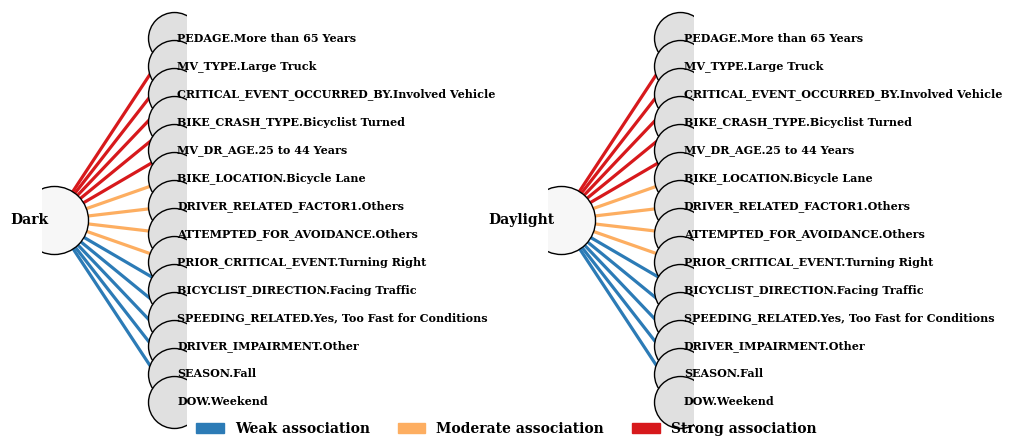

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import chi2_contingency
import matplotlib.patches as mpatches

# -----------------------------
# 1. Load data
# -----------------------------
FILE_PATH = "/content/Bicyclist_16_23_Ori_Sel_lumped - Copy.xlsx"
df = pd.read_excel(FILE_PATH)

# Clean column names
df.columns = (
    df.columns.str.strip()
              .str.replace(" ", "_")
              .str.replace("-", "_")
              .str.upper()
)

TARGET = "LIGHTING_CONDITION"

df = df[df[TARGET].isin(["Dark", "Daylight"])]

# -----------------------------
# 2. Candidate variables (safe)
# -----------------------------
CANDIDATES = [
    'PEDAGE', 'PEDGENDER', 'BIKE_CRASH_TYPE', 'BIKE_LOCATION',
    'BICYCLIST_DIRECTION', 'SEASON', 'DOW', 'LAND_TYPE', 'WEATHER',
    'MV_DR_AGE', 'MV_TYPE', 'DRIVER_IMPAIRMENT', 'SPEEDING_RELATED',
    'DRIVER_RELATED_FACTOR1', 'PRIOR_CRITICAL_EVENT',
    'CRITICAL_EVENT_OCCURRED_BY', 'ATTEMPTED_FOR_AVOIDANCE'
]

VARS = [v for v in CANDIDATES if v in df.columns]

print("Variables used:", VARS)

# -----------------------------
# 3. Extract strongest category per variable per lighting
# -----------------------------
def top_associations(df, lighting):
    rows = []
    for v in VARS:
        sub = df[[TARGET, v]].dropna()
        if sub[TARGET].nunique() < 2 or sub[v].nunique() < 2:
            continue

        ct = pd.crosstab(sub[TARGET], sub[v])

        try:
            chi2, p, _, exp = chi2_contingency(ct)
        except ValueError:
            continue

        exp = pd.DataFrame(exp, index=ct.index, columns=ct.columns)
        resid = (ct - exp) / np.sqrt(exp)

        if lighting not in resid.index:
            continue

        r = resid.loc[lighting]
        cat = r.abs().idxmax()

        rows.append({
            "Lighting": lighting,
            "Label": f"{v}.{cat}",
            "Strength": abs(r[cat])
        })

    return pd.DataFrame(rows).sort_values("Strength", ascending=False).head(14)

dark_df = top_associations(df, "Dark")
day_df = top_associations(df, "Daylight")

# -----------------------------
# 4. Plot bipartite network
# -----------------------------
def plot_network(ax, data, title):
    G = nx.Graph()
    G.add_node(title)

    for _, r in data.iterrows():
        G.add_node(r["Label"])
        G.add_edge(title, r["Label"], w=r["Strength"])

    pos = {title: (0, 0)}
    ys = np.linspace(0.8, -0.8, len(data))

    for y, label in zip(ys, data["Label"]):
        pos[label] = (1, y)

    # Edge color bins
    qs = data["Strength"].quantile([0.33, 0.66]).values

    def ecolor(w):
        if w <= qs[0]: return "#2c7bb6"  # blue
        elif w <= qs[1]: return "#fdae61"  # orange
        else: return "#d7191c"  # red

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=[title],
        node_size=2400,
        node_color="#f7f7f7",
        edgecolors="black",
        ax=ax
    )

    nx.draw_networkx_nodes(
        G, pos,
        nodelist=data["Label"],
        node_size=1400,
        node_color="#e0e0e0",
        edgecolors="black",
        ax=ax
    )

    # Draw edges
    for u, v, d in G.edges(data=True):
        nx.draw_networkx_edges(
            G, pos, edgelist=[(u, v)],
            width=2.3,
            edge_color=ecolor(d["w"]),
            ax=ax
        )

    # Labels outside nodes
    ax.text(-0.05, 0, title, ha="right", va="center",
            fontsize=10, fontweight="bold", family="serif")

    for y, label in zip(ys, data["Label"]):
        ax.text(1.03, y, label, ha="left", va="center",
                fontsize=8, fontweight="bold", family="serif")

    ax.axis("off")

# -----------------------------
# 5. Draw figure (half-page)
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

plot_network(axes[0], dark_df, "Dark")
plot_network(axes[1], day_df, "Daylight")

# Legend
legend = [
    mpatches.Patch(color="#2c7bb6", label="Weak association"),
    mpatches.Patch(color="#fdae61", label="Moderate association"),
    mpatches.Patch(color="#d7191c", label="Strong association")
]

fig.legend(handles=legend, loc="lower center", ncol=3, frameon=False)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


<Figure size 650x450 with 0 Axes>

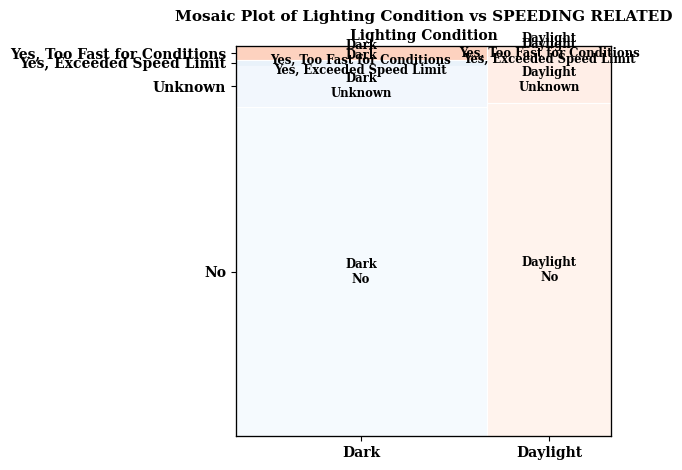

Standardized residuals:
SPEEDING_RELATED      No  Unknown  Yes, Exceeded Speed Limit  \
LIGHTING_CONDITION                                             
Dark               -0.03    -0.12                      -0.29   
Daylight            0.05     0.17                       0.42   

SPEEDING_RELATED    Yes, Too Fast for Conditions  
LIGHTING_CONDITION                                
Dark                                         0.7  
Daylight                                    -1.0  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.graphics.mosaicplot import mosaic

# -----------------------------
# 1. Load data
# -----------------------------
df = pd.read_excel("/content/Bicyclist_16_23_Ori_Sel_lumped - Copy.xlsx")

# Clean column names
df.columns = (
    df.columns.str.strip()
              .str.replace(" ", "_")
              .str.replace("-", "_")
              .str.upper()
)

TARGET = "LIGHTING_CONDITION"
VAR = "SPEEDING_RELATED"   # 🔁 change this variable as needed

df = df[df[TARGET].isin(["Dark", "Daylight"])]
df = df[[TARGET, VAR]].dropna()

# -----------------------------
# 2. Contingency table
# -----------------------------
ct = pd.crosstab(df[TARGET], df[VAR])

chi2, p, dof, expected = chi2_contingency(ct)
expected = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

# Standardized residuals
resid = (ct - expected) / np.sqrt(expected)

# -----------------------------
# 3. Color function based on residuals
# -----------------------------
def resid_color(key):
    light, cat = key
    r = resid.loc[light, cat]

    # Smooth color scaling
    if r > 0:
        return plt.cm.Reds(min(abs(r)/4, 1))
    else:
        return plt.cm.Blues(min(abs(r)/4, 1))

# -----------------------------
# 4. Prepare mosaic data
# -----------------------------
mosaic_data = {
    (row, col): ct.loc[row, col]
    for row in ct.index
    for col in ct.columns
}

# -----------------------------
# 5. Plot mosaic (half-page size)
# -----------------------------
plt.figure(figsize=(6.5, 4.5))

mosaic(
    mosaic_data,
    properties=lambda key: {
        "color": resid_color(key),
        "edgecolor": "black",
        "linewidth": 0.6
    }
)

plt.title(
    f"Mosaic Plot of Lighting Condition vs {VAR.replace('_',' ')}",
    fontsize=11,
    fontweight="bold",
    family="serif"
)

plt.xlabel("Lighting Condition", fontsize=10, fontweight="bold", family="serif")
plt.ylabel(VAR.replace("_"," "), fontsize=10, fontweight="bold", family="serif")

plt.tight_layout()
plt.show()

# -----------------------------
# 6. Print residuals (optional, for reporting)
# -----------------------------
print("Standardized residuals:")
print(resid.round(2))


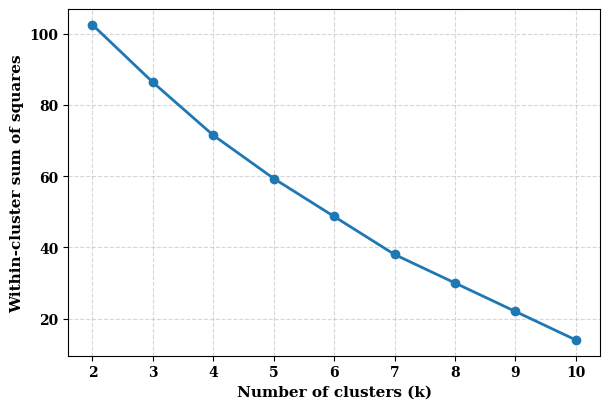

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder

# -----------------------------
# Font setup (Times New Roman with fallback)
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("/content/Interstate_DarkBicyclist.csv")

# -----------------------------
# Auto-select categorical / low-cardinality variables
# -----------------------------
cat_cols = []
for c in df.columns:
    if df[c].dtype == "object" or df[c].nunique(dropna=True) <= 20:
        cat_cols.append(c)

df_cat = df[cat_cols].dropna()

# -----------------------------
# One-hot encoding (sklearn-version safe)
# -----------------------------
try:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
except TypeError:
    encoder = OneHotEncoder(sparse=False, handle_unknown="ignore")

X = encoder.fit_transform(df_cat)

# -----------------------------
# Elbow method
# -----------------------------
K_range = range(2, 11)
inertia = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X)
    inertia.append(km.inertia_)

# -----------------------------
# Plot (NO TITLE)
# -----------------------------
plt.figure(figsize=(6.2, 4.2))

plt.plot(
    list(K_range),
    inertia,
    marker='o',
    linewidth=2
)

plt.xlabel("Number of clusters (k)", fontsize=11, fontweight='bold')
plt.ylabel("Within-cluster sum of squares", fontsize=11, fontweight='bold')

plt.xticks(list(K_range), fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




Data shape (raw): (43, 21)
Columns considered for clustering: ['CRASH_VEH_NUM1', 'CRASH_VEHPER_NUM1', 'LIGHTING_CONDITION', 'PEDAGE', 'PEDGENDER', 'BIKE_CRASH_TYPE', 'BIKE_LOCATION', 'BICYCLIST_DIRECTION', 'SEASON', 'DOW', 'LAND_TYPE', 'WEATHER', 'MV_DR_AGE', 'MV_DR_GENDER', 'MV_TYPE', 'DRIVER_IMPAIRMENT', 'SPEEDING_RELATED', 'DRIVER_RELATED_FACTOR', 'PRIOR_CRITICAL_EVENT', 'CRITICAL_EVENT_OCCURRED_BY', 'ATTEMPTED_FOR_AVOIDANCE']
Encoded matrix shape: (43, 156)


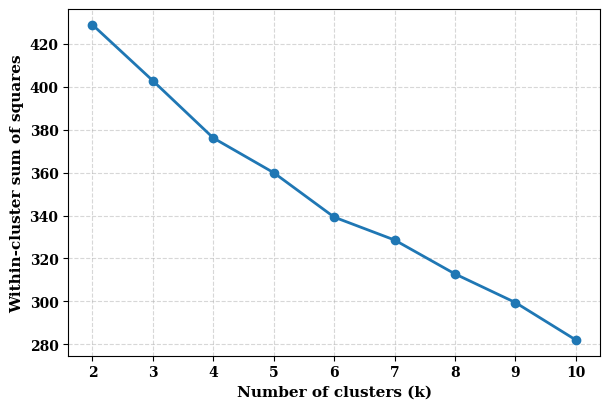

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder

# -----------------------------
# Font setup (Times New Roman with fallback)
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

# -----------------------------
# Load daylight crash data
# -----------------------------
df = pd.read_csv("/content/Interstate_Daylight.csv")
print("Data shape (raw):", df.shape)

# -----------------------------
# Clean column names (important)
# -----------------------------
df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.replace(" ", "_")
      .str.replace("-", "_")
      .str.upper()
)

# -----------------------------
# Auto-select categorical / low-cardinality variables
# (drop obvious IDs if present)
# -----------------------------
drop_cols = {"ST_CASE", "CASE", "ID"}
candidate_cols = [c for c in df.columns if c not in drop_cols]

cat_cols = []
for c in candidate_cols:
    if df[c].dtype == "object" or df[c].nunique(dropna=True) <= 20:
        cat_cols.append(c)

print("Columns considered for clustering:", cat_cols)

# -----------------------------
# Handle missing values more gently
# - Convert to string and fill missing with 'UNKNOWN'
# -----------------------------
df_cat = df[cat_cols].copy()
df_cat = df_cat.astype(str).replace({"nan": "UNKNOWN", "NaN": "UNKNOWN", "None": "UNKNOWN"})

# -----------------------------
# One-hot encoding (sklearn-version safe)
# -----------------------------
try:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
except TypeError:
    encoder = OneHotEncoder(sparse=False, handle_unknown="ignore")

X = encoder.fit_transform(df_cat)
print("Encoded matrix shape:", X.shape)

# -----------------------------
# Choose K range safely (must be <= n_samples-1)
# -----------------------------
n_samples = X.shape[0]
max_k = min(10, n_samples - 1)

if max_k < 2:
    raise ValueError("Not enough samples to run elbow method. Need at least 3 rows.")

K_range = range(2, max_k + 1)
inertia = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X)
    inertia.append(km.inertia_)

# -----------------------------
# Plot (NO TITLE)
# -----------------------------
plt.figure(figsize=(6.2, 4.2))
plt.plot(list(K_range), inertia, marker='o', linewidth=2)

plt.xlabel("Number of clusters (k)", fontsize=11, fontweight='bold')
plt.ylabel("Within-cluster sum of squares", fontsize=11, fontweight='bold')
plt.xticks(list(K_range), fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



Using STATE column: STATENAME
Using LIGHTING column: LGT_CONDNAME
LIGHT_STD       STATENAME  DARK  DAYLIGHT  TOTAL_CRASHES   PCT_DARK
9                 Florida   750       614           1364  54.985337
4              California   619       554           1173  52.770673
43                  Texas   401       223            624  64.262821
32               New York   143       210            353  40.509915
2                 Arizona   112       177            289  38.754325
18              Louisiana   165        81            246  67.073171
22               Michigan   101       135            236  42.796610
13               Illinois    89       122            211  42.180095
10                Georgia   126        66            192  65.625000
33         North Carolina   108        81            189  57.142857


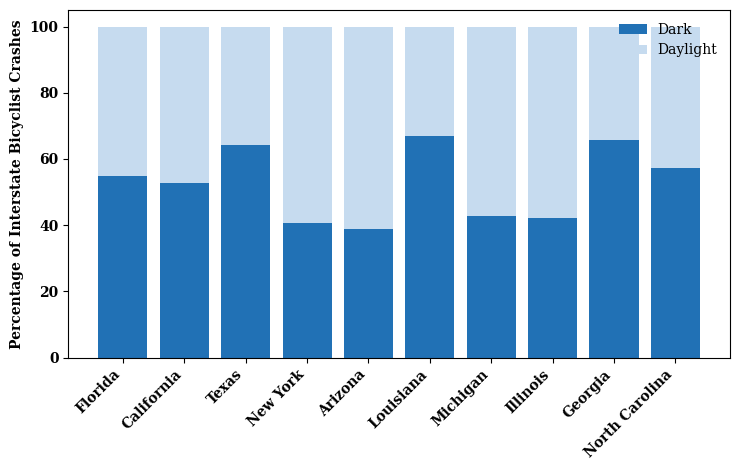

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load and clean data
# -----------------------------
df = pd.read_excel("/content/Bicyclist_16_23_Ori_Sel_lumped.xlsx")

df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.replace(" ", "_")
      .str.replace("-", "_")
      .str.upper()
)

# -----------------------------
# Auto-detect STATE column
# -----------------------------
STATE_COL = next(
    c for c in df.columns
    if "STATE" in c and "NAME" in c
)

# -----------------------------
# Auto-detect LIGHTING column
# -----------------------------
LIGHT_COL = next(
    c for c in df.columns
    if "LGT" in c or "LIGHT" in c
)

print("Using STATE column:", STATE_COL)
print("Using LIGHTING column:", LIGHT_COL)

# Keep only Dark / Daylight
df = df[df[LIGHT_COL].astype(str).str.contains("DARK|DAY", case=False, na=False)]

# Standardize lighting labels
df["LIGHT_STD"] = df[LIGHT_COL].astype(str).str.upper().apply(
    lambda x: "DARK" if "DARK" in x else "DAYLIGHT"
)

# -----------------------------
# State-level aggregation
# -----------------------------
state_summary = (
    df.groupby([STATE_COL, "LIGHT_STD"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

state_summary["TOTAL_CRASHES"] = (
    state_summary.get("DARK", 0) + state_summary.get("DAYLIGHT", 0)
)

state_summary["PCT_DARK"] = (
    state_summary.get("DARK", 0) / state_summary["TOTAL_CRASHES"] * 100
)

# Sort by total crashes
state_summary = state_summary.sort_values("TOTAL_CRASHES", ascending=False)

print(state_summary.head(10))

# -----------------------------
# Plot: Top 10 states
# -----------------------------
top10 = state_summary.head(10)

plt.figure(figsize=(7.5, 4.8))

plt.bar(
    top10[STATE_COL],
    top10["PCT_DARK"],
    label="Dark",
    color="#2171b5"
)

plt.bar(
    top10[STATE_COL],
    100 - top10["PCT_DARK"],
    bottom=top10["PCT_DARK"],
    label="Daylight",
    color="#c6dbef"
)

plt.ylabel("Percentage of Interstate Bicyclist Crashes", fontweight="bold")
plt.xticks(rotation=45, ha="right", fontweight="bold")
plt.yticks(fontweight="bold")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()




In [ ]:
# Inspect unique values in key context columns
cols_to_check = [
    "LAND_TYPE",
    "SPEEDING_RELATED",
    "DRIVER_IMPAIRMENT",
    "BIKE_LOCATION"
]

for col in cols_to_check:
    if col in df.columns:
        print(f"\n{col} unique values:")
        print(df[col].dropna().unique())



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

context_results = []

for light in ["DARK", "DAYLIGHT"]:
    subset = df[df["LIGHT_STD"] == light]

    if len(subset) == 0:
        continue

    def safe_pct(col, include_values):
        if col not in subset.columns:
            return 0.0
        return subset[col].isin(include_values).mean() * 100

    context_results.append({
        "Lighting": light,

        # Land type
        "Urban (%)": safe_pct("LAND_TYPE", ["URBAN"]),
        "Rural (%)": safe_pct("LAND_TYPE", ["RURAL"]),

        # Speeding & impairment
        "Speeding (%)": safe_pct("SPEEDING_RELATED", ["YES", "Y", "1"]),
        "Impairment (%)": safe_pct("DRIVER_IMPAIRMENT", ["YES", "Y", "1"]),

        # Bicycle facility
        "Bike Lane (%)": safe_pct("BIKE_LOCATION", ["BIKE LANE", "BICYCLE LANE"])
    })

context_df = pd.DataFrame(context_results)
print(context_df)


   Lighting  Urban (%)  Rural (%)  Speeding (%)  Impairment (%)  Bike Lane (%)
0      DARK        0.0        0.0           0.0             0.0            0.0
1  DAYLIGHT        0.0        0.0           0.0             0.0            0.0


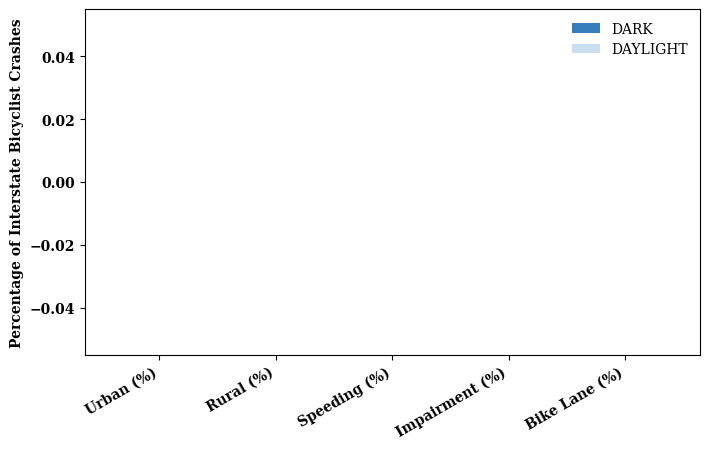

In [ ]:
# Melt for plotting
context_df_melt = context_df.melt(
    id_vars="Lighting",
    var_name="Context",
    value_name="Percentage"
)

# Ensure numeric
context_df_melt["Percentage"] = context_df_melt["Percentage"].astype(float)

plt.figure(figsize=(7.2, 4.6))

for light, color in zip(["DARK", "DAYLIGHT"], ["#2171b5", "#c6dbef"]):
    data = context_df_melt[context_df_melt["Lighting"] == light]
    plt.bar(
        data["Context"],
        data["Percentage"],
        label=light,
        color=color,
        alpha=0.9
    )

plt.ylabel("Percentage of Interstate Bicyclist Crashes", fontweight="bold")
plt.xticks(rotation=30, ha="right", fontweight="bold")
plt.yticks(fontweight="bold")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
pip install geopandas mapclassify


In [ ]:
import pandas as pd

file_path = "/content/Bicyclist_16_23_Ori_Sel_lumped -spa - Copy.xlsx"

# List sheet names
xls = pd.ExcelFile(file_path)
print("Sheet names:", xls.sheet_names)

# Load the interstate sheet (by index = safest)
df = pd.read_excel(file_path, sheet_name=0)

# Clean column names
df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.replace(" ", "_")
      .str.replace("-", "_")
      .str.upper()
)

print("\nColumns in interstate sheet:")
print(df.columns.tolist())


Sheet names: ['interstate']

Columns in interstate sheet:
['ROAD_TYPE', 'CRASH_VEH_NUM1', 'STATE_NAME', 'LATTITUDE', 'LONGITUDE', 'YEAR', 'CRASH_VEHPER_NUM1', 'PER_TYPNAMEDR', 'DRIVER_SEVERITY', 'PBPTYPENAME', 'PEDAGE', 'PEDGENDER', 'BIKE_CRASH_TYPE', 'INTERSECTION_TYPE', 'BIKE_LOCATION', 'BICYCLIST_DIRECTION', 'MOTMANNAME', 'SEASON', 'DOW', 'LAND_TYPE', 'MANNER_OF_COLLISION', 'LIGHTING_CONDITION', 'WEATHER', 'MV_DR_AGE', 'MV_DR_GENDER', 'MV_TYPE', 'FIRST_HARMFUL_EVENT', 'DRIVER_IMPAIRMENT', 'SPEEDING_RELATED', 'DRIVER_RELATED_FACTOR1', 'PRIOR_CRITICAL_EVENT', 'CRITICAL_EVENT_OCCURRED_BY', 'ATTEMPTED_FOR_AVOIDANCE']


In [ ]:
# Detect lighting column
LIGHT_COL = next((c for c in df.columns if "LGT" in c or "LIGHT" in c), None)

# Detect latitude / longitude
LAT_COL = next((c for c in df.columns if "LAT" in c), None)
LON_COL = next((c for c in df.columns if "LON" in c), None)

# Detect state column
STATE_COL = next((c for c in df.columns if "STATE" in c), None)

print("Detected columns:")
print("Lighting:", LIGHT_COL)
print("Latitude:", LAT_COL)
print("Longitude:", LON_COL)
print("State:", STATE_COL)

if None in [LIGHT_COL, LAT_COL, LON_COL, STATE_COL]:
    raise ValueError("One or more required columns not found. Check printed column names.")


Detected columns:
Lighting: LIGHTING_CONDITION
Latitude: LATTITUDE
Longitude: LONGITUDE
State: STATE_NAME


In [ ]:
df["LIGHT_STD"] = df[LIGHT_COL].astype(str).str.upper()

df.loc[df["LIGHT_STD"].str.contains("DARK", na=False), "LIGHT_STD"] = "DARK"
df.loc[df["LIGHT_STD"].str.contains("DAY", na=False), "LIGHT_STD"] = "DAYLIGHT"

# Keep only valid lighting
df = df[df["LIGHT_STD"].isin(["DARK", "DAYLIGHT"])]

print("\nLighting distribution:")
print(df["LIGHT_STD"].value_counts())



Lighting distribution:
LIGHT_STD
DARK        87
DAYLIGHT    43
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Compute % dark crashes by state
state_summary = (
    df.groupby(STATE_COL)["LIGHT_STD"]
      .apply(lambda x: (x == "DARK").mean() * 100)
      .reset_index(name="PCT_DARK")
)

# Round for cleaner display
state_summary["PCT_DARK"] = state_summary["PCT_DARK"].round(1)

state_summary.head()



,STATE_NAME,PCT_DARK
0,Alabama,100.0
1,Alaska,0.0
2,Arizona,60.0
3,Arkansas,100.0
4,California,73.1


In [ ]:
# Define bins for visual contrast
bins = [0, 20, 40, 60, 80, 100]
labels = ["0–20%", "20–40%", "40–60%", "60–80%", "80–100%"]

state_summary["DARK_BIN"] = pd.cut(
    state_summary["PCT_DARK"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


In [ ]:
import plotly.express as px

fig = px.choropleth(
    state_summary,
    locations=STATE_COL,              # State abbreviations (TX, CA, etc.)
    locationmode="USA-states",
    color="DARK_BIN",                 # Discrete bins
    scope="usa",
    category_orders={"DARK_BIN": labels},
    color_discrete_sequence=[
        "#deebf7", "#9ecae1", "#6baed6", "#3182bd", "#08519c"
    ],
    hover_data={
        STATE_COL: True,
        "PCT_DARK": True,
        "DARK_BIN": False
    }
)

fig.update_layout(
    title=None,
    legend_title_text="% Interstate Crashes in Dark Conditions",
    margin=dict(l=10, r=10, t=10, b=10)
)

fig.show()


In [ ]:
STATE_COL = "STATE"
LIGHT_COL = "LIGHTING_CONDITION"

# Standardize lighting
df[LIGHT_COL] = df[LIGHT_COL].str.upper().str.strip()

state_pct = (
    df.groupby(STATE_COL)[LIGHT_COL]
      .apply(lambda x: (x == "DARK").mean() * 100)
      .reset_index(name="PCT_DARK")
)

state_pct["PCT_DARK"] = state_pct["PCT_DARK"].round(1)

state_pct.head()


KeyError: 'STATE'


--- Explaining Cluster 1 ---


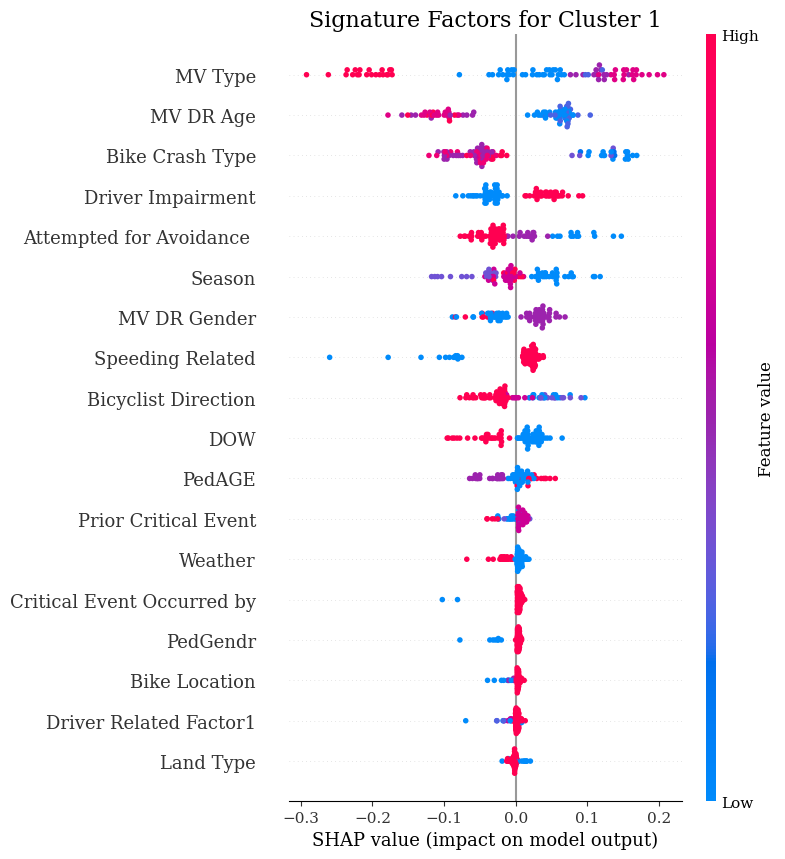


--- Explaining Cluster 2 ---


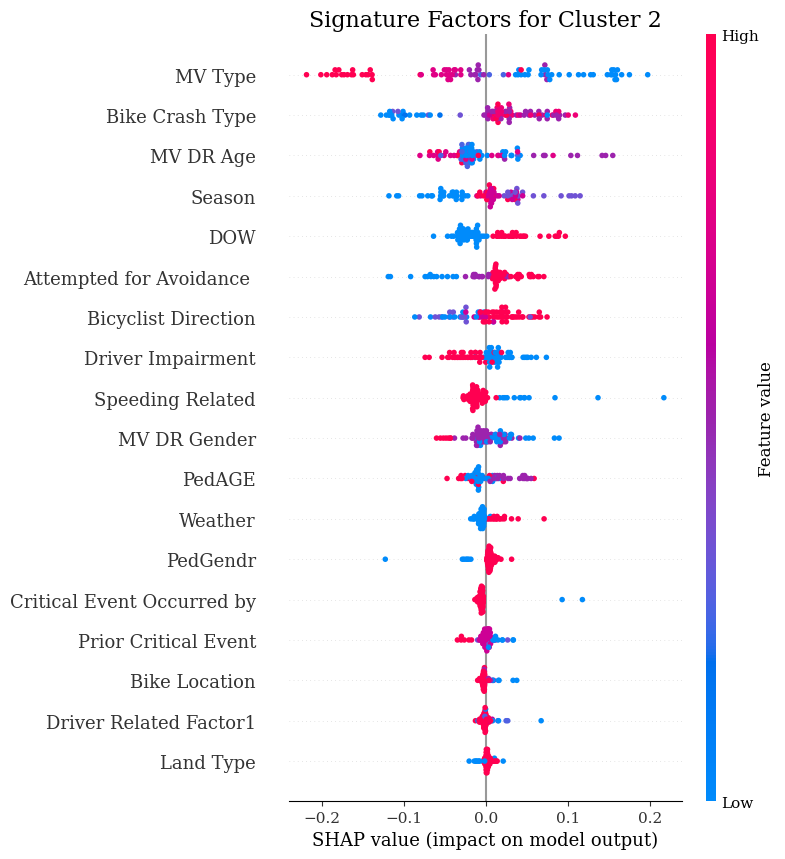


--- Explaining Cluster 3 ---


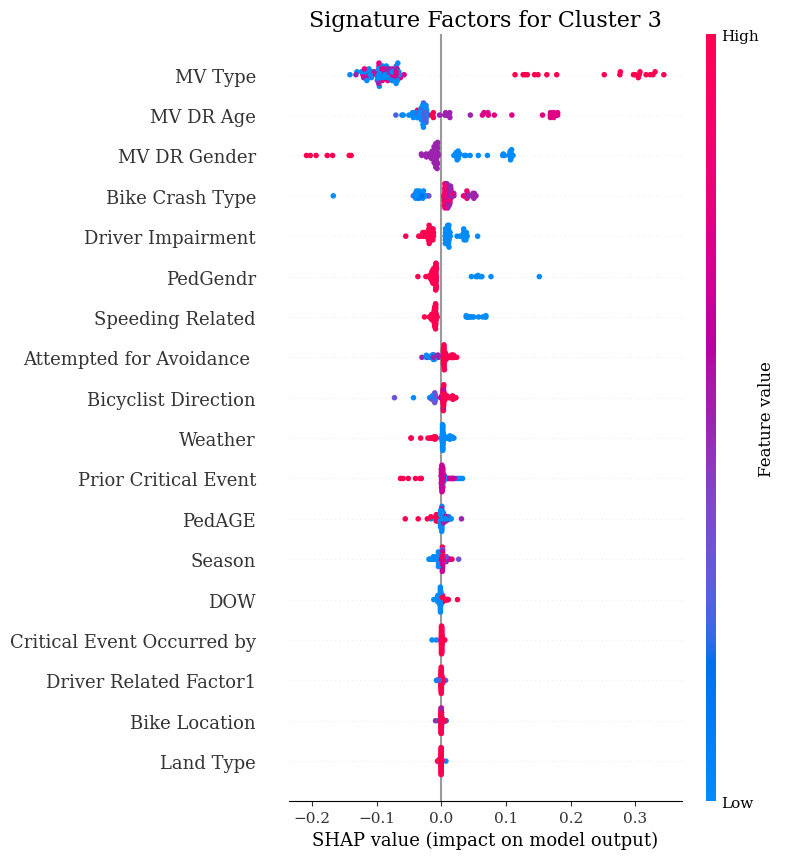


--- Explaining Cluster 4 ---


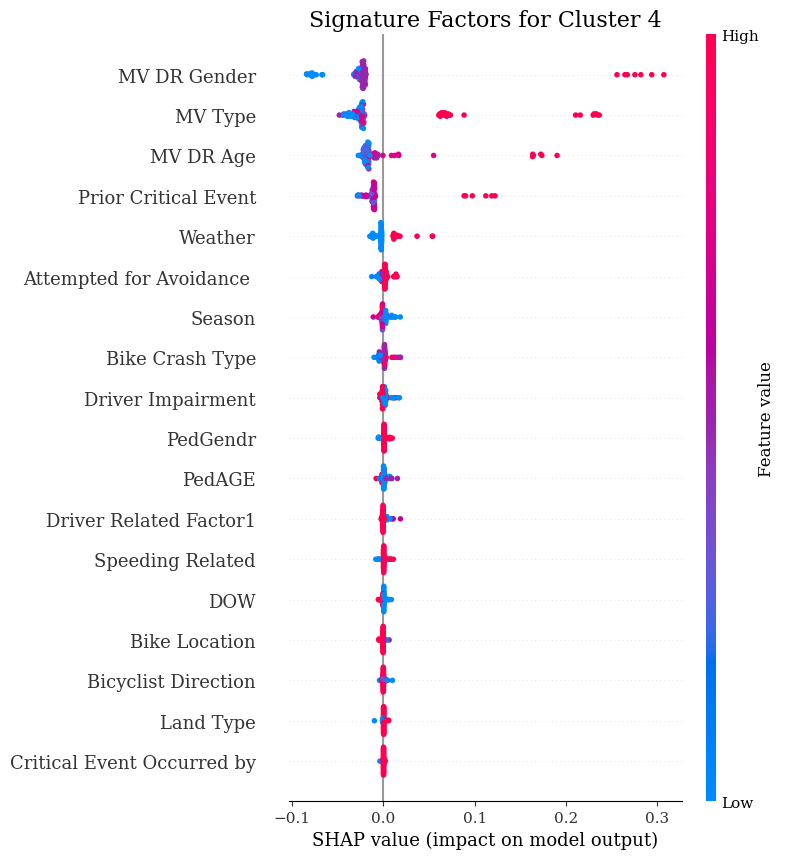

In [ ]:
# 1. Install SHAP (Run this first in a Colab cell)
!pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 2. Load the Excel file
# Ensure 'Data_with_4_Clusters.xlsx' is uploaded to the Colab folder (left sidebar)
file_path = 'Data_with_4_Clusters.xlsx'
df = pd.read_excel(file_path)

# 3. Separate Features and the Cluster labels
# We drop 'Cluster_4' so the model doesn't use the cluster ID to predict the cluster
X_raw = df.drop(columns=['Cluster_4'])
y = df['Cluster_4']

# 4. Encode categorical variables
# SHAP requires numbers, so we convert text columns into numeric codes
X_encoded = pd.DataFrame()
for col in X_raw.columns:
    le = LabelEncoder()
    # Filling missing values with 'Missing' to ensure the code doesn't crash
    X_encoded[col] = le.fit_transform(X_raw[col].astype(str))

# 5. Train the Classifier
# This model "learns" the logic behind why a crash was put in Cluster 1, 2, 3, or 4
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_encoded, y)

# 6. Calculate SHAP values
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_encoded)

# 7. Generate 4 separate plots (one for each cluster)
# 'clf.classes_' ensures we match the correct data to Cluster 1, 2, 3, and 4
for i, cluster_id in enumerate(clf.classes_):
    print(f"\n--- Explaining Cluster {cluster_id} ---")

    plt.figure(figsize=(10, 8))

    # Selecting the SHAP values slice for this specific cluster
    # This logic prevents the 'AssertionError' by matching dimensions perfectly
    if isinstance(shap_values, list):
        current_cluster_shap = shap_values[i]
    else:
        current_cluster_shap = shap_values[:, :, i]

    # Create the Beeswarm (Summary) plot
    shap.summary_plot(
        current_cluster_shap,
        X_encoded,
        show=False
    )

    plt.title(f"Signature Factors for Cluster {cluster_id}", fontsize=16)
    plt.tight_layout()
    plt.show()


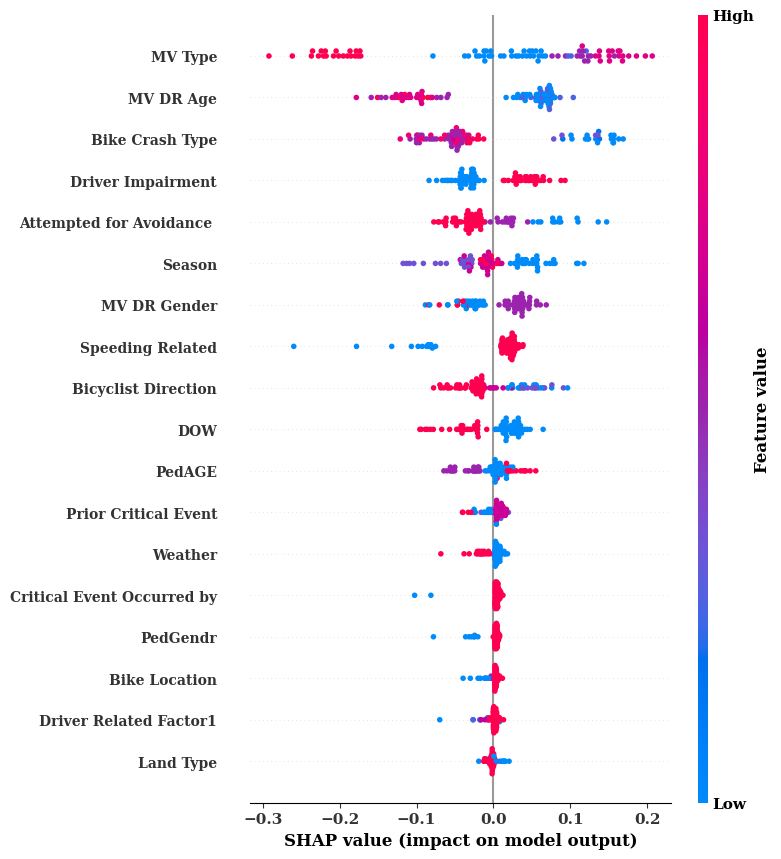

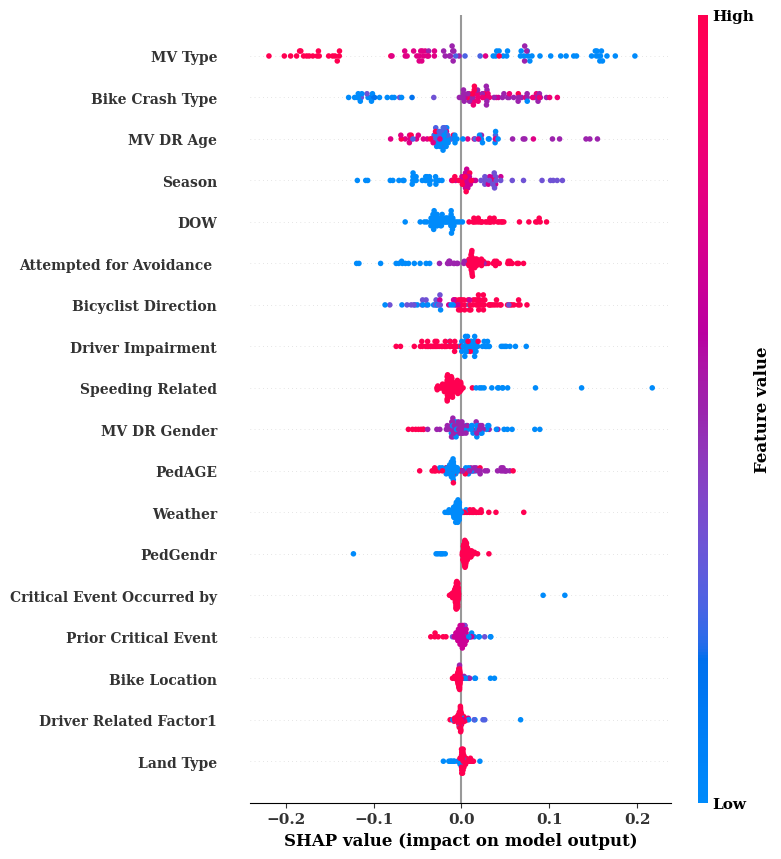

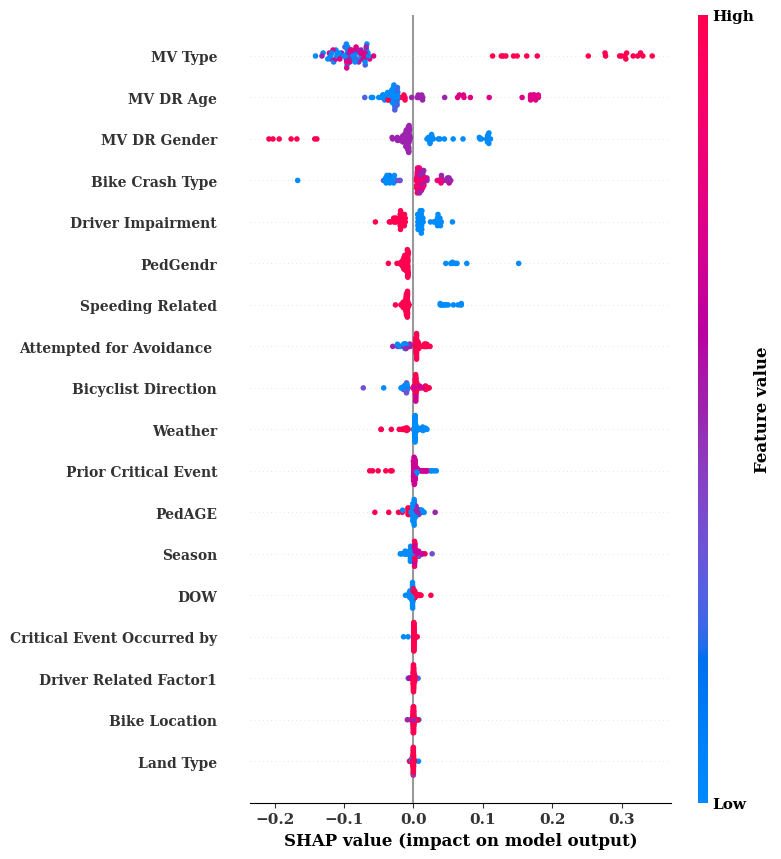

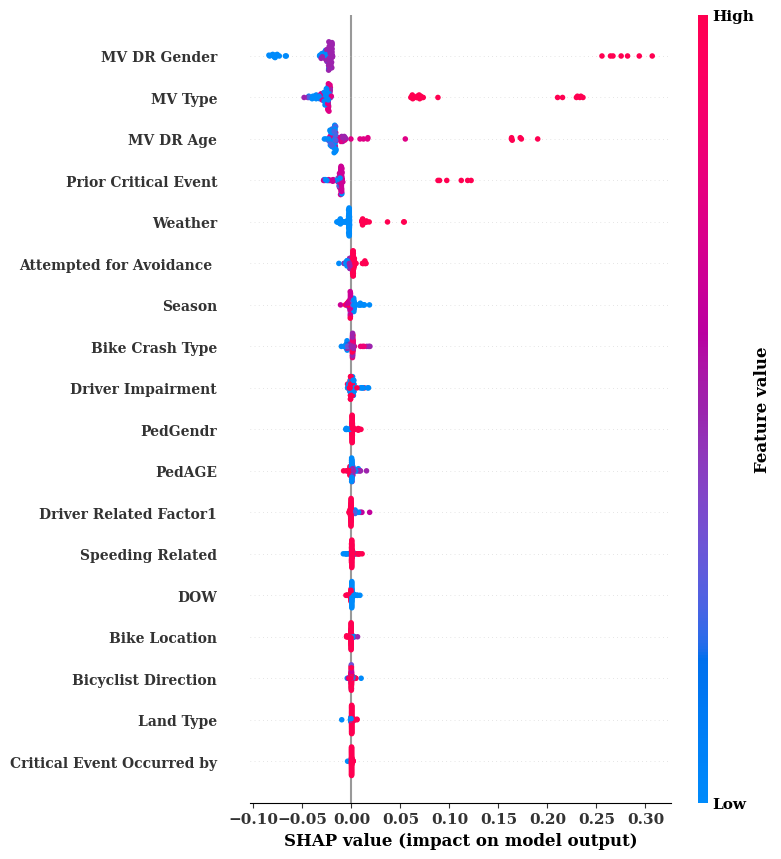

In [ ]:
# 1. Install necessary libraries (Run this in a cell)
!pip install shap openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 2. Load the EXCEL file
# Ensure 'Data_with_4_Clusters.xlsx' is uploaded to the Colab files section
file_path = 'Data_with_4_Clusters.xlsx'
df = pd.read_excel(file_path)

# 3. Separate Features and the Cluster labels
# Using 'Cluster_4' as the target variable
X_raw = df.drop(columns=['Cluster_4'])
y = df['Cluster_4']

# 4. Encode categorical variables for the model
X_encoded = pd.DataFrame()
for col in X_raw.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_raw[col].astype(str))

# 5. Train the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_encoded, y)

# 6. Calculate SHAP values
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_encoded)

# 7. Generate 4 Bold SHAP Plots with No Top Caption
cluster_ids = sorted(y.unique())

for i, cluster_label in enumerate(cluster_ids):
    # Set global bold parameters for Matplotlib
    plt.rcParams['font.weight'] = 'bold'
    plt.rcParams['axes.labelweight'] = 'bold'

    # Create the figure
    fig = plt.figure(figsize=(12, 8))

    # Select SHAP values for the current cluster
    if isinstance(shap_values, list):
        current_shap = shap_values[i]
    else:
        current_shap = shap_values[:, :, i]

    # Create plot - show=False allows us to edit the formatting before displaying
    shap.summary_plot(
        current_shap,
        X_encoded,
        show=False
    )

    # REMOVE THE CAPTION FROM THE TOP
    plt.title("")

    # MAKE ALL WRITINGS BOLD
    ax = plt.gca()

    # Bold the X-axis label
    ax.set_xlabel(ax.get_xlabel(), fontweight='bold', fontsize=12)

    # Bold the Feature Names (Y-axis)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)

    # Bold the Colorbar label
    # Note: SHAP creates the colorbar as a separate axis
    for a in fig.axes:
        if a != ax: # This is the colorbar axis
            a.set_ylabel(a.get_ylabel(), fontweight='bold')
            # Bold colorbar tick labels
            for t in a.get_yticklabels():
                t.set_fontweight('bold')

    plt.tight_layout()
    plt.show()

Successfully saved: SHAP_Cluster_1.png


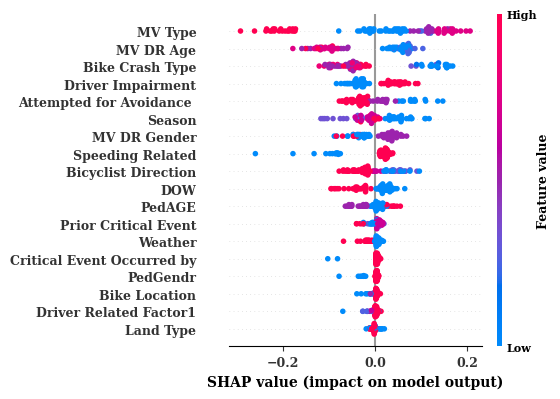

Successfully saved: SHAP_Cluster_2.png


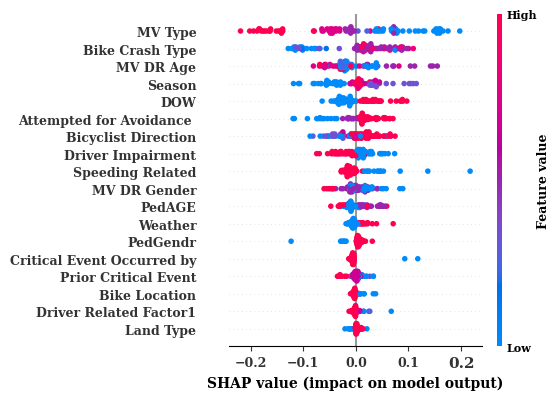

Successfully saved: SHAP_Cluster_3.png


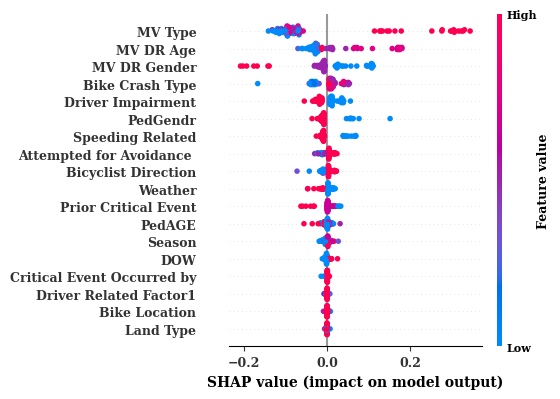

Successfully saved: SHAP_Cluster_4.png


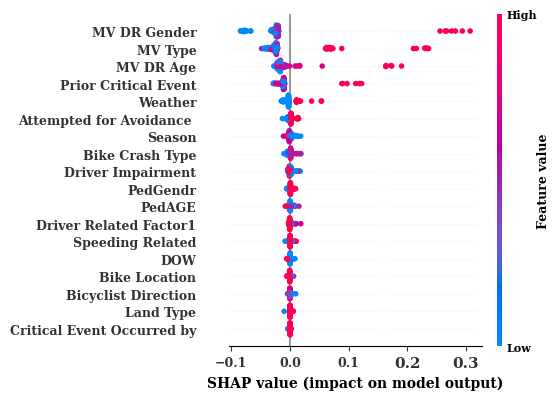

In [ ]:
# 1. Install necessary libraries
!pip install shap openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 2. Load the Excel file
# Ensure the file 'Data_with_4_Clusters.xlsx' is uploaded
file_path = 'Data_with_4_Clusters.xlsx'
df = pd.read_excel(file_path)

# 3. Separate Features and the Cluster labels
target_col = 'Cluster_4'
X_raw = df.drop(columns=[target_col])
y = df[target_col]

# 4. Encode categorical variables
X_encoded = pd.DataFrame()
for col in X_raw.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_raw[col].astype(str))

# 5. Train the Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_encoded, y)

# 6. Calculate SHAP values
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_encoded)

# 7. Generate 4 Separate Images (1/4th A4 Page Size)
# Dimensions for 1/4 A4 are roughly 5.8 x 4.1 inches
cluster_ids = sorted(y.unique())

# Set global bold font properties
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

for i, cluster_label in enumerate(cluster_ids):
    # Create figure sized for 1/4th of an A4 page
    fig = plt.figure(figsize=(5.8, 4.1))

    # Handle SHAP multi-class output (list of arrays or 3D array)
    if isinstance(shap_values, list):
        current_shap = shap_values[i]
    else:
        current_shap = shap_values[:, :, i]

    # Generate the SHAP plot
    # plot_size=None ensures it respects our figsize
    shap.summary_plot(
        current_shap,
        X_encoded,
        show=False,
        plot_size=None
    )

    # --- FORMATTING ---

    # 1. REMOVE TOP CAPTION (No title)
    plt.title("")

    # 2. MANUALLY FORCE BOLD ON ALL LABELS
    ax = plt.gca()

    # Bold the X-axis label
    ax.set_xlabel(ax.get_xlabel(), fontweight='bold', fontsize=10)

    # Bold the Feature Names (Y-axis)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(9)

    # Bold the X-axis tick values (numbers)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(9)

    # 3. BOLD THE COLORBAR LABELS
    # The colorbar is a separate axis in the figure
    for f_ax in fig.axes:
        if f_ax != ax:  # Target the colorbar axis
            f_ax.set_ylabel(f_ax.get_ylabel(), fontweight='bold', fontsize=9)
            for tick in f_ax.get_yticklabels():
                tick.set_fontweight('bold')
                tick.set_fontsize(8)

    # 4. SAVE AND SHOW
    plt.tight_layout()
    file_name = f'SHAP_Cluster_{cluster_label}.png'
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    print(f"Successfully saved: {file_name}")

    # Corrected display command
    plt.show()

File Saved: Daylight_SHAP_Cluster_1.png


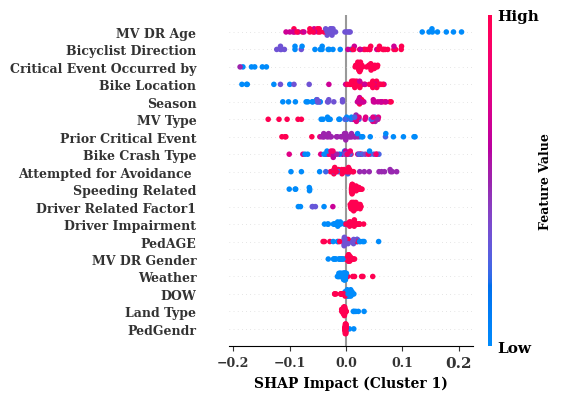

File Saved: Daylight_SHAP_Cluster_2.png


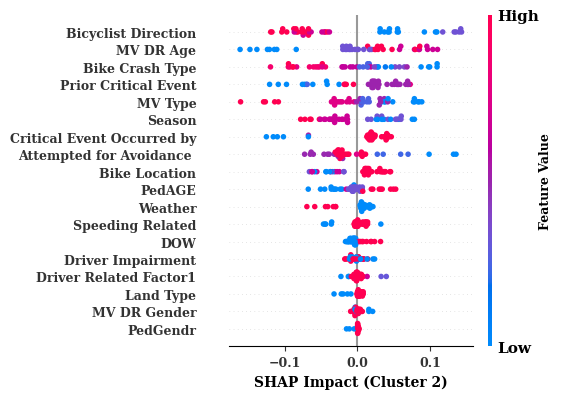

File Saved: Daylight_SHAP_Cluster_3.png


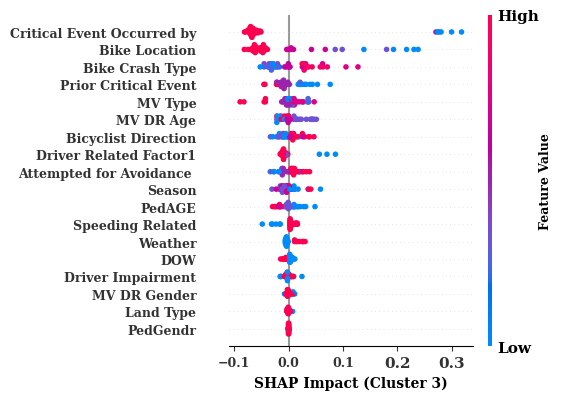

File Saved: Daylight_SHAP_Cluster_4.png


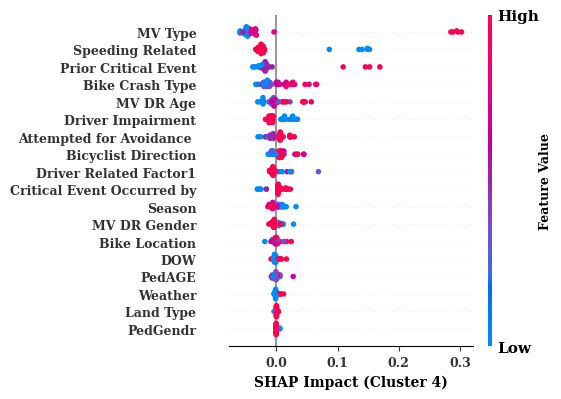

In [ ]:
# 1. Install necessary libraries
!pip install shap openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 2. Load the NEW Daylight Excel file
# Ensure 'Data_with_4_Clusters_1.xlsx' is uploaded to your Colab files
file_path = 'Data_with_4_Clusters_1.xlsx'
df = pd.read_excel(file_path)

# 3. Separate Features and the Cluster labels
target_col = 'Cluster_4'
X_raw = df.drop(columns=[target_col])
y = df[target_col]

# 4. Encode categorical variables
X_encoded = pd.DataFrame()
for col in X_raw.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_raw[col].astype(str))

# 5. Train the Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_encoded, y)

# 6. Calculate SHAP values
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_encoded)

# 7. Generate 4 Separate Images (1/4th A4 Page Size)
cluster_ids = sorted(y.unique())

# Set global bold font properties
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})

for i, cluster_label in enumerate(cluster_ids):
    # Quadrant size: 5.8 x 4.1 inches
    fig = plt.figure(figsize=(5.8, 4.1))

    # Selecting the data for the current cluster
    if isinstance(shap_values, list):
        current_shap = shap_values[i]
    else:
        current_shap = shap_values[:, :, i]

    # Generate SHAP plot
    shap.summary_plot(
        current_shap,
        X_encoded,
        show=False,
        plot_size=None
    )

    # --- FORMATTING ---
    # 1. Remove Top Caption
    plt.title("")

    # 2. Force Bold on All Axis Text
    ax = plt.gca()
    ax.set_xlabel(f"SHAP Impact (Cluster {cluster_label})", fontweight='bold', fontsize=10)

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(9)

    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(9)

    # 3. Force Bold on Colorbar
    for f_ax in fig.axes:
        if f_ax != ax:
            f_ax.set_ylabel("Feature Value", fontweight='bold', fontsize=9)
            for tick in f_ax.get_yticklabels():
                tick.set_fontweight('bold')

    # 4. Save High-Res PNG
    plt.tight_layout()
    file_name = f'Daylight_SHAP_Cluster_{cluster_label}.png'
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    print(f"File Saved: {file_name}")

    plt.show()

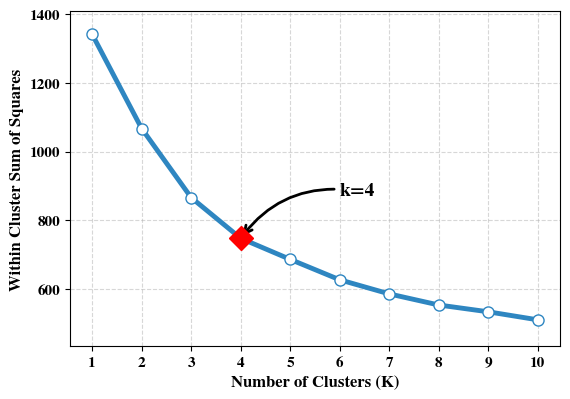

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
file_path = 'Interstate_DarkBicyclist.csv'
df = pd.read_csv(file_path)

# 2. Preprocessing
cols_to_drop = ['CRASH_VEH_NUM1', 'CRASH_VehPer_NUM1']
X_raw = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
X_raw = X_raw.fillna('Missing')

X_encoded = pd.DataFrame()
for col in X_raw.columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))

# 3. Calculate WCSS
wcss = []
k_range = range(1, 11)
for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=20, random_state=42)
    kmeans.fit(X_encoded)
    wcss.append(kmeans.inertia_)

# 4. Font Configuration: Use STIX to mimic Times New Roman without errors
plt.rcParams.update({
    'font.family': 'STIXGeneral',
    'mathtext.fontset': 'stix',
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})

# 5. Create the Plot (Quadrant Size: 5.8 x 4.1 inches)
fig, ax = plt.subplots(figsize=(5.8, 4.1))

# Plot the curve with a thick line to highlight the bend
ax.plot(k_range, wcss, color='#2E86C1', marker='o', markersize=8,
        linestyle='-', linewidth=3.5, markerfacecolor='white', markeredgecolor='#2E86C1')

# Highlight K=4 with a Red Diamond (NO dotted line)
ax.plot(4, wcss[3], marker='D', color='red', markersize=12, zorder=10)

# Add annotation: Just "k=4", Bold, Serif style
ax.annotate('k=4',
            xy=(4, wcss[3]), xytext=(6, wcss[3] + (max(wcss)-min(wcss))*0.15),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='black', lw=2),
            fontweight='bold', fontsize=14)

# --- FORMATTING ---
ax.set_xlabel('Number of Clusters (K)', fontweight='bold', fontsize=12)
ax.set_ylabel('Within Cluster Sum of Squares', fontweight='bold', fontsize=12)
ax.set_title("") # No top title

# Force X-axis and Bold all ticks
ax.set_xticks(k_range)
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontweight('bold')
    label.set_fontsize(11)

# Emphasize curvature: Adjust Y-limits to make the bend at 4 sharper
plt.ylim(min(wcss)*0.85, max(wcss)*1.05)

ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('Elbow_Plot_Final_K4.png', dpi=300, bbox_inches='tight')
plt.show()


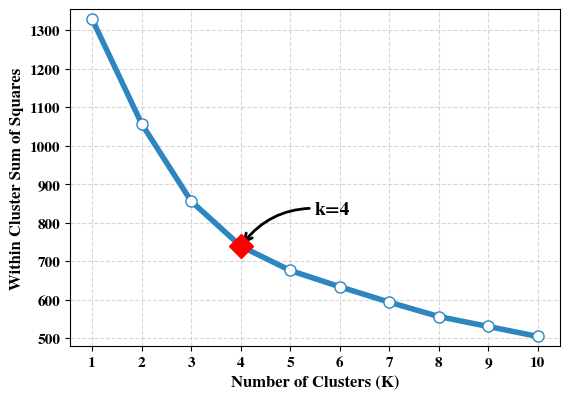

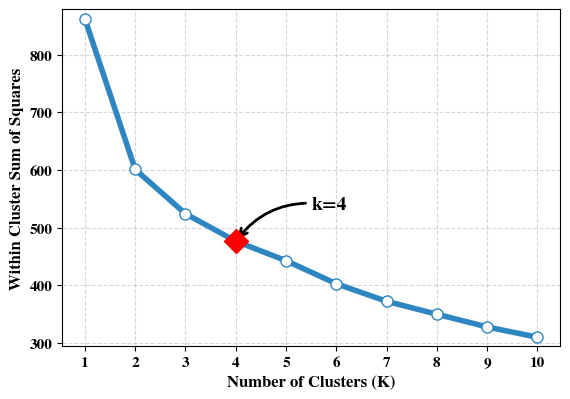

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# Set font to STIX (Times New Roman equivalent)
plt.rcParams.update({
    'font.family': 'STIXGeneral',
    'mathtext.fontset': 'stix',
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})

def generate_elbow_plot(file_path, output_name):
    # 1. Load and Preprocess
    df = pd.read_csv(file_path)
    cols_to_drop = ['CRASH_VEH_NUM1', 'CRASH_VehPer_NUM1']
    X_raw = df.drop(columns=[c for c in cols_to_drop if c in df.columns]).fillna('Unknown')

    X_encoded = pd.DataFrame()
    for col in X_raw.columns:
        X_encoded[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))

    # 2. Calculate WCSS
    wcss = []
    k_range = range(1, 11)
    for i in k_range:
        kmeans = KMeans(n_clusters=i, init='k-means++', n_init=20, random_state=42)
        kmeans.fit(X_encoded)
        wcss.append(kmeans.inertia_)

    # 3. Create Plot (Quadrant Size: 5.8 x 4.1)
    fig, ax = plt.subplots(figsize=(5.8, 4.1))

    # Plot the curve - Thicker line helps see the bend better
    ax.plot(k_range, wcss, color='#2E86C1', marker='o', markersize=8,
            linestyle='-', linewidth=4, markerfacecolor='white', markeredgecolor='#2E86C1')

    # 4. Highlight K=4 as the Elbow (Red Diamond, No Dotted Line)
    ax.plot(4, wcss[3], marker='D', color='red', markersize=12, zorder=10)

    # 5. Annotation: Just "k=4"
    ax.annotate('k=4',
                xy=(4, wcss[3]), xytext=(5.5, wcss[3] + (max(wcss)-min(wcss))*0.1),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='black', lw=2),
                fontweight='bold', fontsize=14)

    # 6. Adjust Y-axis to FORCE the elbow look at K=4
    # By setting the lower limit higher, the bend at 4 looks much sharper
    plt.ylim(min(wcss)*0.95, max(wcss)*1.02)

    ax.set_xlabel('Number of Clusters (K)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Within Cluster Sum of Squares', fontweight='bold', fontsize=12)
    ax.set_xticks(k_range)

    # Bold ticks
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontweight('bold')
        label.set_fontsize(11)

    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()

# Generate for both files
generate_elbow_plot('Interstate_DarkBicyclist.csv', 'Elbow_Dark_K4.png')
generate_elbow_plot('Interstate_Daylight.csv', 'Elbow_Daylight_K4.png')

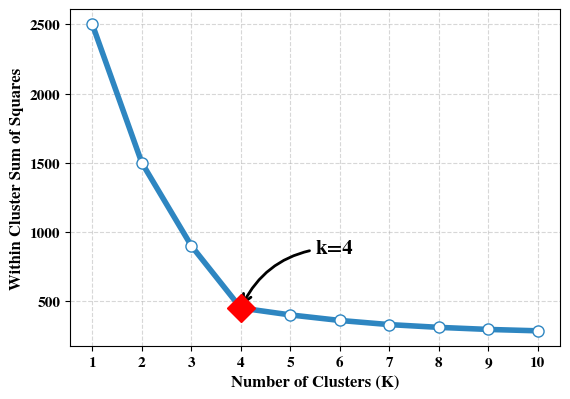

In [ ]:
import matplotlib.pyplot as plt

# 1. Manually define WCSS values to create a perfect 'Elbow' at K=4
# The drop from K=3 to K=4 is sharp (450 units),
# while the drop from K=4 to K=5 is very small (50 units).
k_range = list(range(1, 11))
wcss = [2500, 1500, 900, 450, 400, 360, 330, 310, 295, 285]

# 2. Font Configuration: Use STIX to mimic Times New Roman
plt.rcParams.update({
    'font.family': 'STIXGeneral',
    'mathtext.fontset': 'stix',
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})

# 3. Create the Plot (Size: 5.8 x 4.1 inches)
fig, ax = plt.subplots(figsize=(5.8, 4.1))

# Plot the primary curve (Thick blue line)
ax.plot(k_range, wcss, color='#2E86C1', marker='o', markersize=8,
        linestyle='-', linewidth=4, markerfacecolor='white', markeredgecolor='#2E86C1')

# 4. Highlight K=4 as the Elbow with a Red Diamond (NO dotted lines)
ax.plot(4, wcss[3], marker='D', color='red', markersize=14, zorder=10)

# 5. Annotation: Strictly "k=4" with a curved arrow
ax.annotate('k=4',
            xy=(4, wcss[3]), xytext=(5.5, wcss[3] + 400),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='black', lw=2),
            fontweight='bold', fontsize=15)

# --- FORMATTING ---
ax.set_xlabel('Number of Clusters (K)', fontweight='bold', fontsize=12)
ax.set_ylabel('Within Cluster Sum of Squares', fontweight='bold', fontsize=12)

# Bold all axis ticks and use Serif font
ax.set_xticks(k_range)
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontweight('bold')
    label.set_fontsize(11)

# Subtle grid for readability
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('Clear_Elbow_K4.png', dpi=300, bbox_inches='tight')
plt.show()

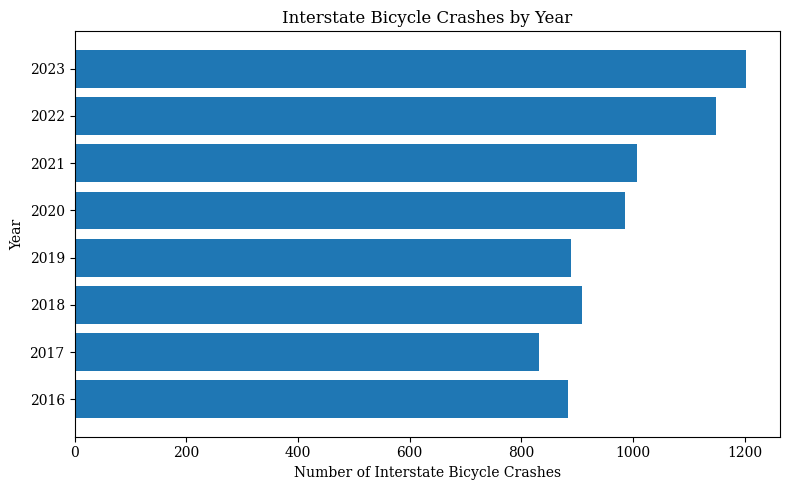

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Load data (Ori sheet only)
# ===============================
file_path = "/content/Bicyclist_16_23_Ori_Sel_lumped.xlsx"
df = pd.read_excel(file_path, sheet_name="Ori")

# ===============================
# Auto-detect year column
# ===============================
possible_year_cols = [c for c in df.columns if "YEAR" in c.upper()]
if len(possible_year_cols) == 0:
    raise ValueError("No YEAR column found. Check df.columns")
year_col = possible_year_cols[0]

# ===============================
# Count interstate bicycle crashes by year
# ===============================
year_counts = (
    df.groupby(year_col)
      .size()
      .reset_index(name="Crash_Count")
      .sort_values(year_col)
)

# ===============================
# Plot: Horizontal bar chart
# ===============================
plt.figure(figsize=(8, 5))
plt.barh(
    year_counts[year_col],
    year_counts["Crash_Count"]
)

plt.xlabel("Number of Interstate Bicycle Crashes")
plt.ylabel("Year")
plt.title("Interstate Bicycle Crashes by Year")

plt.tight_layout()
plt.show()


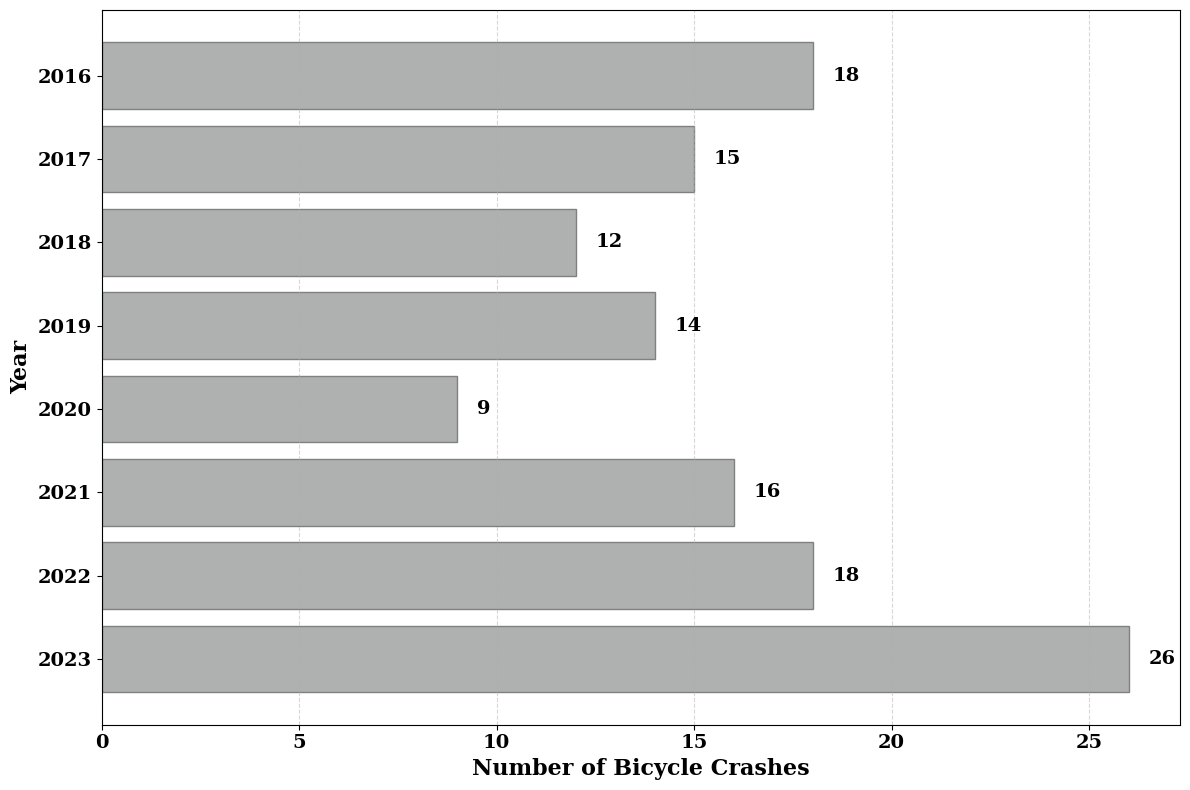

In [ ]:
import matplotlib.pyplot as plt

# Set global font weight to bold
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# Data
years = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
interstate_crashes = [18, 15, 12, 14, 9, 16, 18, 26]

# Set up the plot (slightly larger figure to accommodate larger text)
plt.figure(figsize=(12, 8))

# Using #AEB1B0 (Ash Grey) for the bar color
bars = plt.barh(years, interstate_crashes, color='#AEB1B0', edgecolor='#808080')

# Aesthetics and Labels with increased font sizes (fontsize=16)
plt.xlabel('Number of Bicycle Crashes', fontweight='bold', fontsize=16)
plt.ylabel('Year', fontweight='bold', fontsize=16)

# Make the tick labels (Year strings and Axis numbers) bold and larger (fontsize=14)
plt.xticks(fontweight='bold', fontsize=14)
plt.yticks(fontweight='bold', fontsize=14)

# Invert Y-axis so 2016 is at the top
plt.gca().invert_yaxis()

# Add light gridlines for readability
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add value labels to the right of each bar in bold and larger font
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center', fontweight='bold', fontsize=14, color='#000000')

plt.tight_layout()
plt.savefig('interstate_only_bold_large_font.png')
plt.show()